### Pendahuluan

Apa yang Dikatakan oleh UCI Dataset

Sebelum mengujikan model atau algoritma AI apa yang akan kita gunakan, ada baiknya untuk mengetahui isi dari UCI Dataset. Adapun sebagai berikut isi data yang akan saya jabarkan pengertiannya dan nantinya dalam bentuk tabel korelasi:

Penjelasan setiap kolom pada tabel:

-  Age (Umur): Kolom berisi umur dari pasien

-  Sex (Jenis Kelamin) : Kolom berisi jenis kelamin pasien
    - 0 = Perempuan
    - 1 = Laki-laki

-  Cp (Chest Pain) : Jenis nyeri dada yang dialami pasien, disini ada 4 nilai yaitu
    - 0 = Typical Angina: Nyeri dada karena kurangnya darah dan oksigen ke jantung.
    - 1 = Atypical Angina: Nyeri dada yang tidak berhubungan dengan jantung.
    - 2 = Non-anginal Pain: Biasanya berupa nyeri tajam yang bukan karena masalah jantung (misal: sakit ulu hati).
    - 3 = Asymptomatic: Tidak ada gejala nyeri, tetapi ada tanda medis gangguan jantung.

-  Trestbps (Resting Blood Pressure): Tekanan darah pasien saat istirahat (satuan mm Hg saat masuk rumah sakit). Di atas 130-140 biasanya menjadi perhatian medis.

-  Chol (Serum Cholestoral): Kadar kolesterol dalam darah (satuan mg/dl).

-  Fbs (Fasting Blood Sugar): Gula darah puasa.
    - 0 = <= 120 mg/dl (Normal)
    - 1 = > 120 mg/dl (Tinggi/Diabetes)

-  Restecg (Resting Electrocardiographic Results): Hasil elektrokardiogram saat istirahat.
    - 0 = Normal
    - 1 = Memiliki kelainan gelombang ST-T.
    - 2 = Menunjukkan kemungkinan hipertrofi (penebalan) bilik kiri jantung.

-  Thalach (Maximum Heart Rate Achieved): Detak jantung maksimal yang dicapai saat melakukan aktivitas/tes fisik.

-  Exang (Exercise Induced Angina): Apakah olahraga memicu nyeri dada
    - 0 = Tidak
    - 1 = Ya

-  Oldpeak (ST depression): Penurunan segmen ST yang dipicu oleh olahraga relatif terhadap saat istirahat (mengukur tingkat stres jantung).

-  Slope (The Slope of the Peak Exercise ST Segment): Kemiringan segmen ST pada puncak latihan fisik.
    - 0 = Upsloping (Cenderung lebih baik)
    - 1 = Flat (Data menunjukkan tanda masalah)
    - 2 = Downsloping (Tanda masalah jantung yang signifikan)

-  Ca (Number of Major Vessels): Jumlah pembuluh darah utama (0-3) yang terlihat melalui prosedur fluoroscopy. Semakin banyak pembuluh darah yang "terlihat" jelas (tidak tersumbat), semakin baik.

-  Thal (Thalassemia): Hasil tes darah Thalassemia.
    - 1 = Normal
    - 2 = Fixed defect (Cacat permanen)
    - 3 = Reversable defect (Cacat yang bisa pulih)

-  Target (Diagnosis): Status penyakit jantung.
    - 0 = Sehat (Tidak ada penyakit jantung)
    - 1 = Sakit (Terdeteksi penyakit jantung)
  
Adapun data diatas saya tuliskan berdasarkan deskripsi umum, dan jika ada informasi yang kurang relevan atau ada masukan akan saya terima dan gunakan untuk melengkapi desripsi yang kurang relevan.

### 1. Modul yang digunakan

In [2]:
%matplotlib inline
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


### 2. UCI Dataset

In [3]:
df = pd.read_csv('../data/heart.csv')
df_heart = pd.DataFrame(
    df,
    columns=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
)
print(df_heart.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


### 3. Check Missing Value or Outliner Data

In [4]:
df_heart.isna().sum() # Check apakah ada data yang bernilai NA

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df_heart.nunique() # Untuk mengetahui jumlah nilai pada setiap kolom

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

### 4. Korelasi Data



Berisi korelasi data yang harus diperhatikan untuk mentraining dan test AI. Disini terdapat data yang harus diperhatikan karena korelasinya cukup berpengaruh untuk menentukan target yaitu cp, thalach, exang, oldpeak, slope, dan ca.

<Axes: title={'center': 'Tabel Korelasi'}>

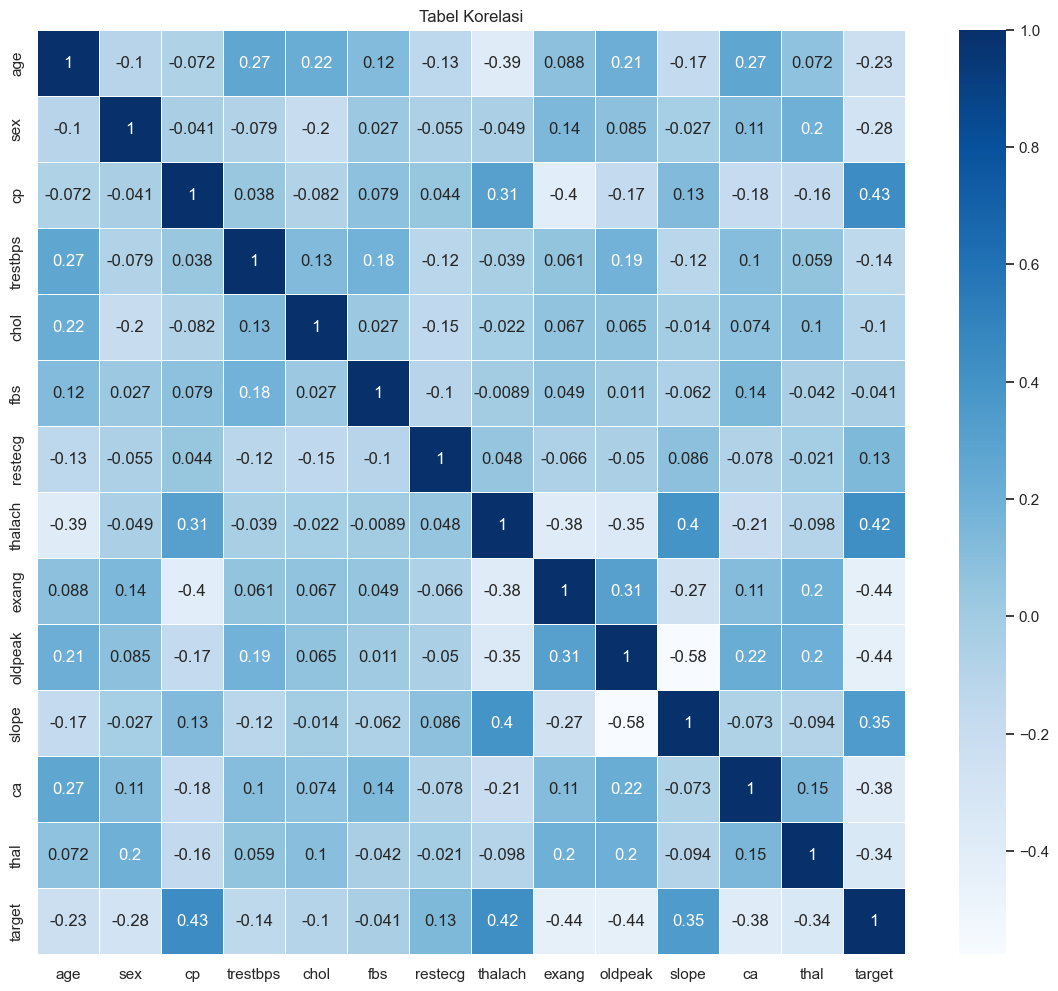

In [6]:
corelasi = df_heart.corr() # Data disimpan di variabel corelasi

sns.set_theme()
f, ax = plt.subplots(figsize=(14, 12))
ax.set_title("Tabel Korelasi")
sns.heatmap(corelasi, annot=True, linewidths=.5, ax=ax,cmap="Blues" )

### 5. Visualisasi Data 

Akan saya visualisasikan data yang perlu diperhatikan untuk penilaian model.

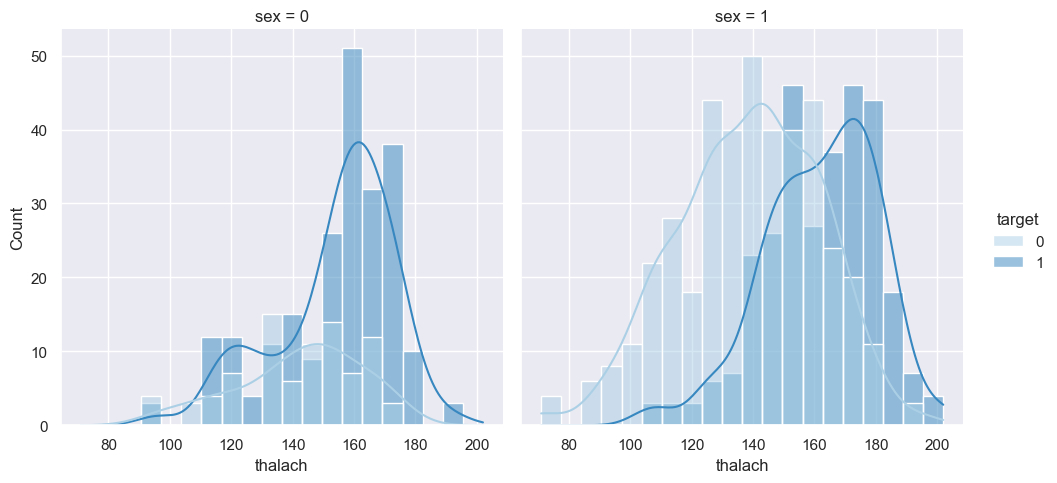

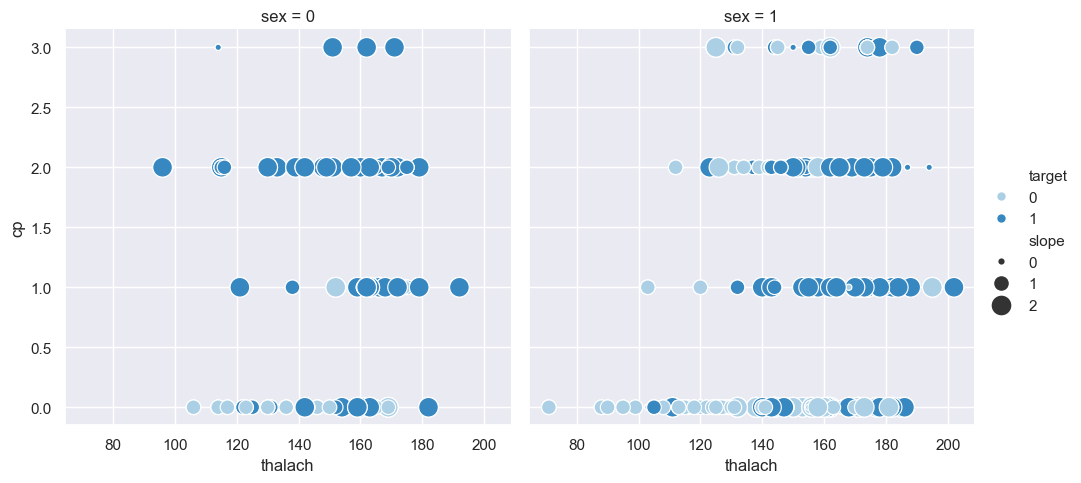

In [7]:
sns.displot(df_heart, x="thalach", hue="target", col="sex", palette='Blues', kde=True) # Diagram plot
sns.relplot(df_heart, x="thalach", y="cp", col="sex", hue="target", size="slope", sizes=(20,200), palette="Blues")

Pada tabel diatas, ditemukan bahwa rata-rata pasien sakit memiliki thalach(Maximum Heart Rate Achieved) dikisaran 160-180. Kemudian kita crosskan dengan korelasi yang berhubungan dengan thalach. Dimana cp(Atypical Angina, non-anginal pain), slope(flat,downsloping) perlu diperhatikan. Ditemukan juga jumlah pasien laki-laki lebih banyak daripada perempuan, namun perbandingan antara yang sakit dan sehat ditemukan perempuan lebih banyak jadi dapat saya simpulkan pasien perempuan lebih rentan.

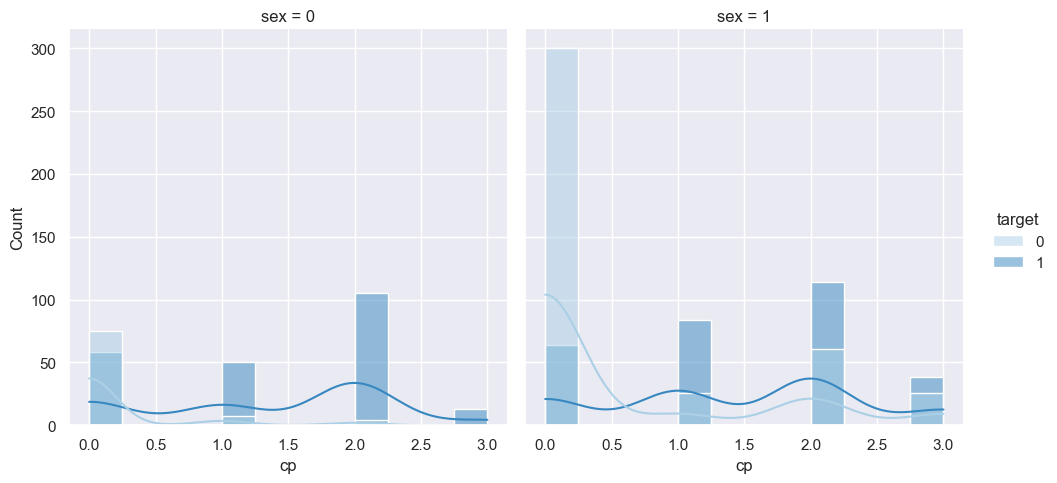

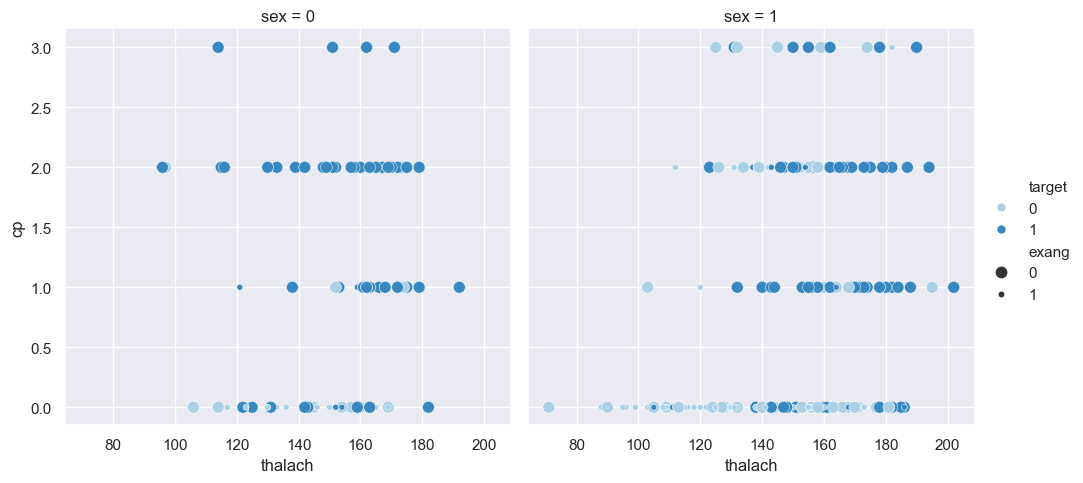

In [8]:
warna = "Blues"
sns.displot(df_heart ,x="cp", hue="target", col="sex",kde=True, palette=warna)
sns.relplot(df_heart ,x="thalach", y="cp", hue="target", col="sex", size="exang", palette=warna)

Setelah diketahui pasien sakit rata-rata memiliki masalah di Atypical Angina dan Non-anginal Pain, kita crosskan juga dengan tabel thalach dan exang.

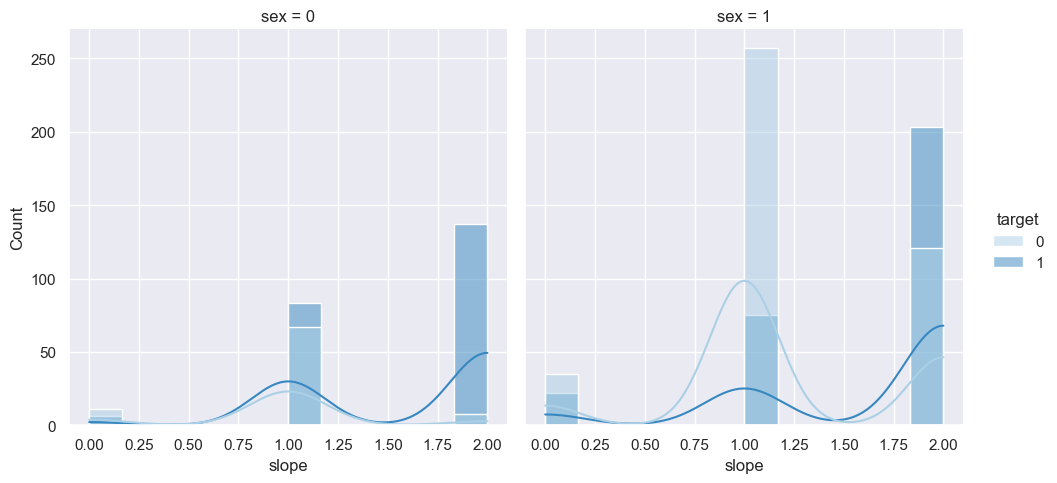

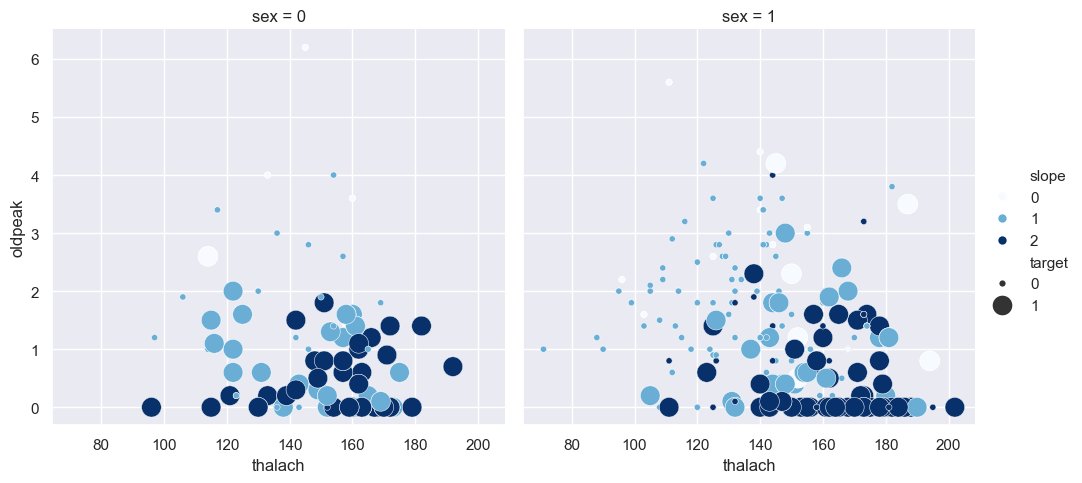

In [9]:
sns.displot(df_heart, x="slope", hue="target", col="sex", kde=True, palette=warna)
sns.relplot(df_heart,x="thalach", y="oldpeak", hue="slope", col="sex", size="target",sizes=(200,20), palette=warna)

Karena korelasi antara tabel slope, thalach dan oldpeak cukup kuat maka kita crosskan juga untuk mengetahui target sakit dan sehat.

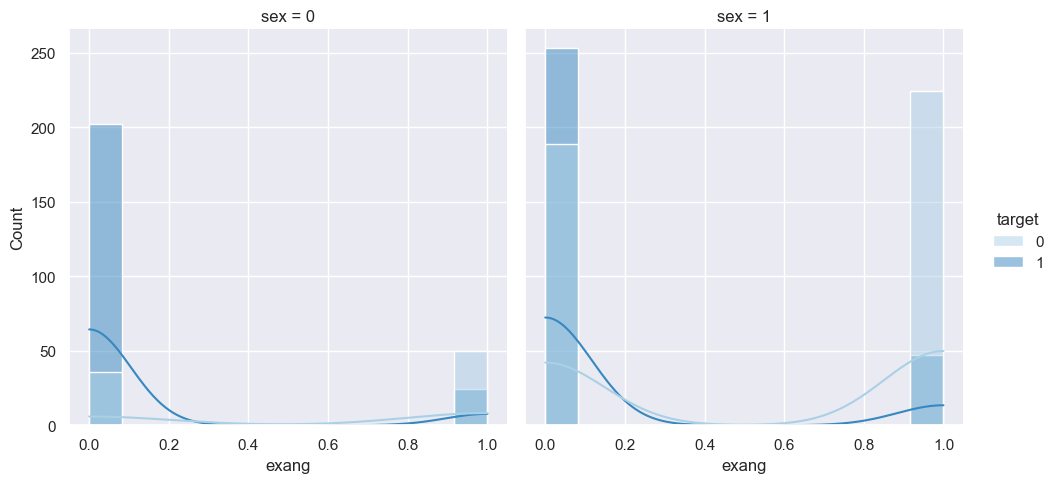

In [10]:
sns.displot(df_heart,x="exang", hue="target", col="sex",kde=True, palette=warna)

Setelah kita crosskan dengan target ditemukan jumlah sakit lebih banyak walaupun tidak memiliki nyeri dada saat olahraga, jadi bisa disimpulkan korelasi terhadap target tidak terlalu kuat / pasien tetap berada dikategori sakit walaupun baik-baik saja saat melakukan test exang. Maka fitur ini bisa pastikan tidak terlalu berpengaruh untuk target.

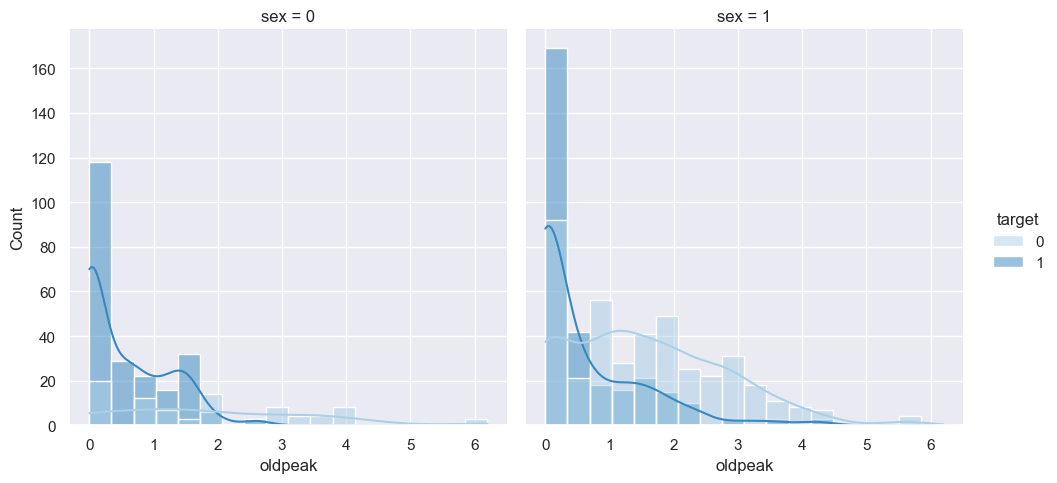

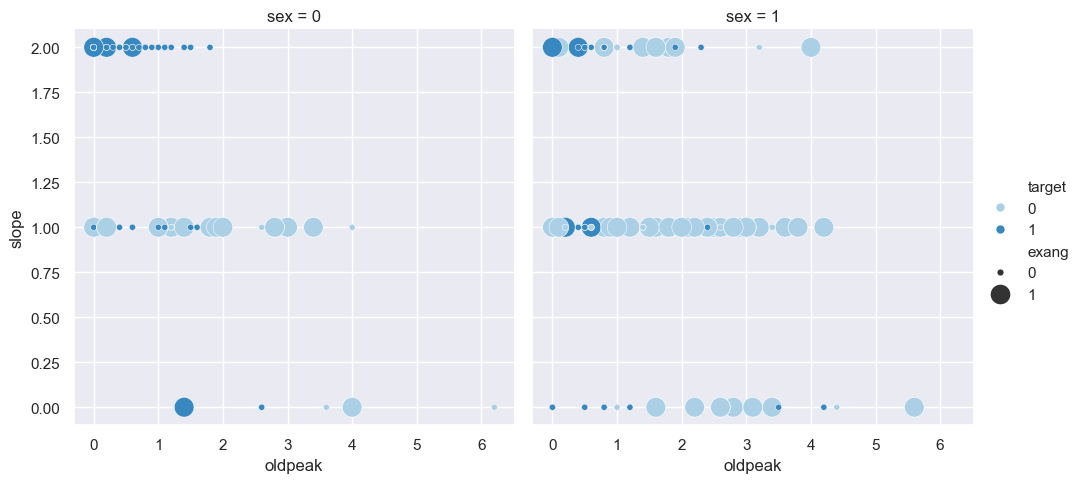

In [11]:
sns.displot(df_heart,kde=True,palette=warna,x="oldpeak", hue="target", col="sex")
sns.relplot(df_heart, palette=warna, x="oldpeak", y="slope", hue="target", size="exang",sizes=(200,20), col="sex")

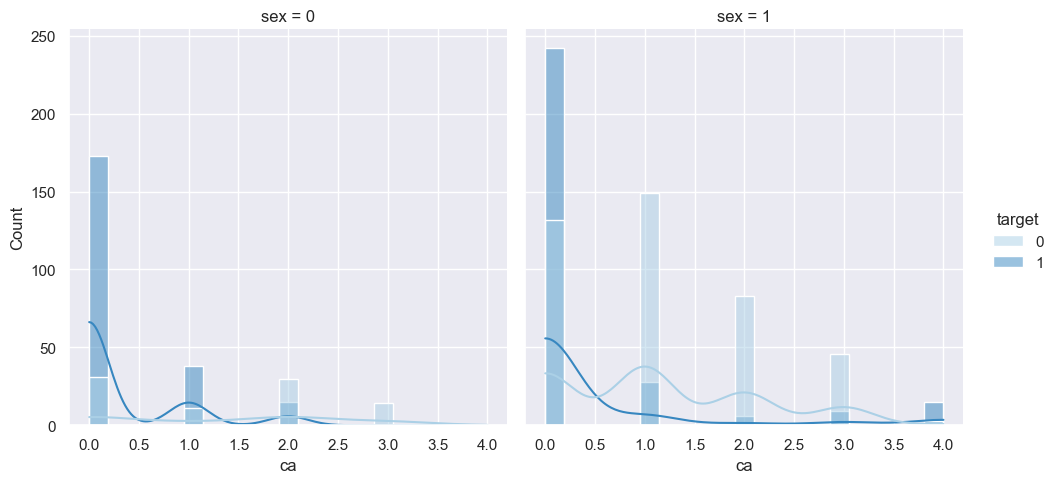

In [12]:
sns.displot(df_heart, palette=warna, kde=True, x="ca", col="sex", hue="target")

Dapat kita lihat, semakin sedikit jumlah pembuluh darah utama(tersumbat) maka semakin buruk kondisi jantung

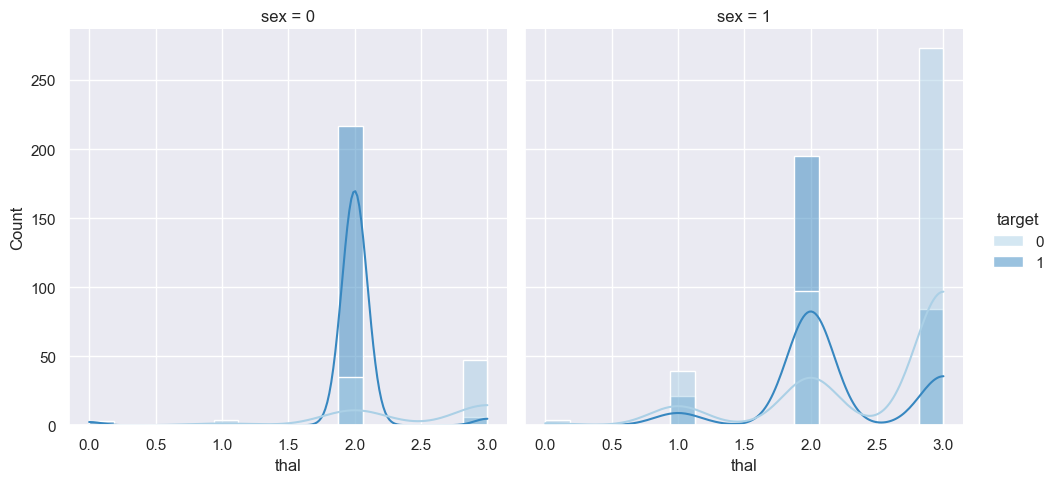

In [13]:
sns.displot(df_heart, x="thal", hue="target", col="sex", kde=True, palette=warna)

In [14]:
from plotly.express import scatter

pg = scatter(df_heart, x="age", y="chol", color="target", hover_data=['cp','trestbps','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal'], width=(1000), height=(600), title="Tabel Kategori")
pg


Diagram sebar sederhana untuk melihat kategori sakit dan sehat ditentukan oleh apa saja

In [15]:
df_heart.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


Tabel untuk bahan pengecekkan nilai rata-rata, min, max dll

### 6. Model Scikit Learn

Saya akan menggunakan model Random Forest Classifer. Pada model Random Forest logikanya adalah beberapa pohon yang mengambil keputusan dan melakukan voting berdasarkan suara terbanyak, model ini juga rawan overfitting maka harus melakukan setting parameter dan melakukan cross validasi score.

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Estimator yang digunakan
from sklearn.model_selection import train_test_split, cross_val_score # Untuk membagi data dan evaluasi score dengan metode cross validasi
from sklearn.metrics import accuracy_score # Untuk mengecek score
from sklearn.pipeline import make_pipeline # Menggabungkan ke pipeline


X = df_heart.drop(columns=['target'])
y = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)
model = RandomForestClassifier(n_estimators=100, # Parameter random forest
                               max_depth=4, # Kedalaman pohon 
                               min_samples_split=10, # Jumlah sampel yang dibutuhkan untuk membelah node
                               min_samples_leaf=10, # Jumlah sampel yang dibutuhkan di node daun
                               max_features="sqrt", 
                               max_leaf_nodes=None, 
                               bootstrap=True,
                               oob_score=True,
                               random_state=1,
                               )
pipeline = make_pipeline(model)
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
scores = cross_val_score(model,X,y)

print(f"Score data pelatihan: {model.score(X_train,y_train):.2f}")
print(f"Score validasi silang : {scores.mean():.2f}")
print(f"Score data test :{accuracy_score(y_test, y_pred):.2f}")


Score data pelatihan: 0.89
Score validasi silang : 0.88
Score data test :0.87


### 7. Penilaian Model

Setelah kita menentukan estimator yang akan digunakan dan melakukan penyetingan parameter estimator tersebut, perlu kita ketahui juga bagaimana sebuah model melakukan penilaian, adapun akan saya jabarkan sebagai berikut:

1. Confusion Matrix

Disini kita akan melihat perbandingan bagaimana model memprediksi pasien dan data sebenarnya dilapangan. 

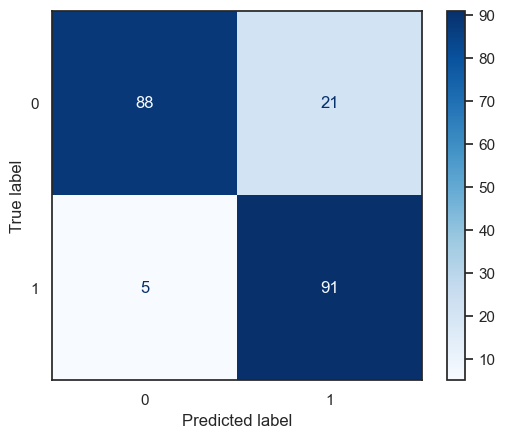

In [17]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=model.classes_)
displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
sns. set_theme(context='notebook', style='white')
displ.plot(cmap="Blues")

Pada tabel diatas, pasien sehat yang diprediksi sehat(True Negative) = 88, kemudian pasien sehat namun diprediksi sakit(False Positive) = 21, pasien sakit diprediksi sehat(False Negative) = 5, dan pasien sakit yang diprediksi sakit(True Positive) = 91.

2. classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.81      0.87       109
           1       0.81      0.95      0.88        96

    accuracy                           0.87       205
   macro avg       0.88      0.88      0.87       205
weighted avg       0.88      0.87      0.87       205



Presisi adalah rasio jumlah True Positive dan False Positive (TP/(TP+FP)) atau jika dimodel ini adalah seberapa akurat model untuk memprediksi pasien sakit, sedangkan recall adalah rasio jumlah True Positive dan False Negative (TP/(TP+FN)) atau jika dimodel ini adalah seberapa banyak model benar-benar menebak semua orang yang benar-benar sakit, dan untuk f1-score adalah rata-rata harmonik tertimbang dari presisi dan recall.

3. Fiture Importance

Text(0.5, 1.0, 'Feature Importance')

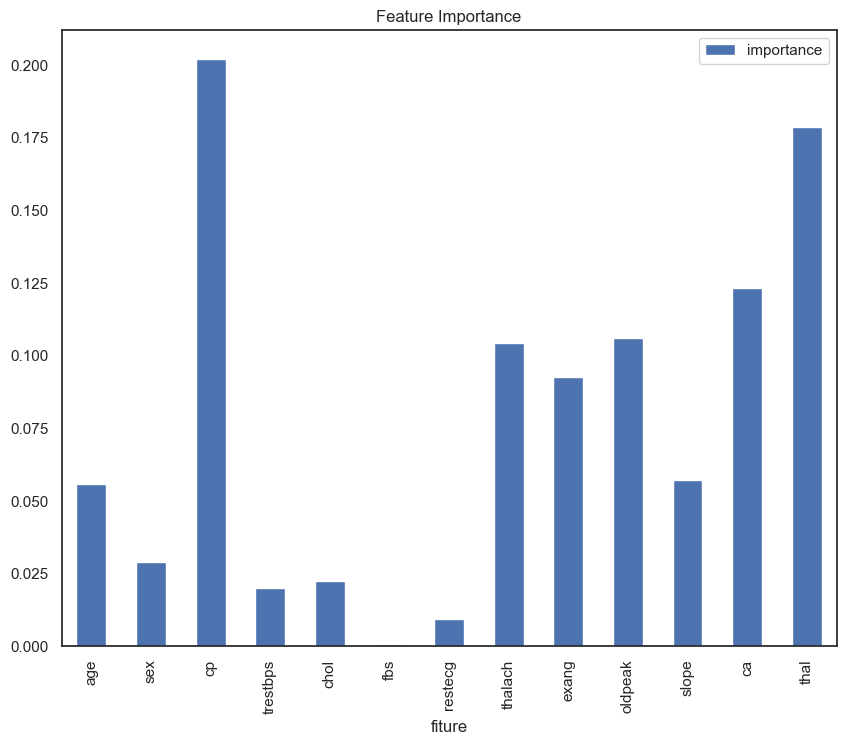

In [19]:
fitur = model.feature_importances_
fiture_name = X.columns
fiture_importance = pd.DataFrame({
    'fiture':fiture_name,
    'importance':fitur
})
fiture_importance.sort_values(by='importance', ascending=False)

fig, ax = plt.subplots(figsize=(10,8))
fiture_importance.plot.bar(x='fiture',y='importance', ax=ax)
ax.set_title('Feature Importance')
